# Time-Series Signal Analysis: Training Inputs & Post-Enforcement Outputs

In [2]:
# Import required libraries
import os
import glob
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Configuration
PRIMARY_SIGNALS = [
    "FLOWCOOLPRESSURE",
    "FLOWCOOLFLOWRATE",
    "IONGAUGEPRESSURE",
    "ETCHBEAMCURRENT",
    "ETCHSUPPRESSORCURRENT",
    "ETCHSOURCEUSAGE",
    "ACTUALSTEPDURATION",
]

TRAIN_DATA_DIR = "./data/train"
ENFORCER_RESULTS_PATH = "./results/enforcer_outputs/enforcement_results.pkl"
ENFORCER_REPORT_PATH = "./results/enforcer_outputs/enforcement_report.json"
ALARM_EVENTS_PATH = "./results/enforcer_inputs/alarm_events.pkl"

SAMPLING_RATE = 4  # seconds
ALPHA_HOURS = 3
ALPHA = (ALPHA_HOURS * 3600) // SAMPLING_RATE  # 2700 samples

print(f"Analyzing {len(PRIMARY_SIGNALS)} primary signals")
print(f"Alpha window: {ALPHA} samples ({ALPHA_HOURS} hours)")

Analyzing 7 primary signals
Alpha window: 2700 samples (3 hours)


---
# Part 1: Original Signal Analysis (Training Inputs)

This section analyzes the 7 primary signals used during model training.

## 1.1 Data Loading

In [4]:
# Load training data from multiple machines
train_files = sorted(glob.glob(os.path.join(TRAIN_DATA_DIR, "*_DC_train.csv")))
print(f"Found {len(train_files)} training files")

# Load and concatenate all training data
all_signals_data = {sig: [] for sig in PRIMARY_SIGNALS}
all_signals_data['time'] = []
all_signals_data['machine_id'] = []

for file in train_files[:5]:  # Load first 5 machines for analysis
    machine_id = os.path.basename(file).replace("_DC_train.csv", "")
    df = pd.read_csv(file)
    
    for sig in PRIMARY_SIGNALS:
        if sig in df.columns:
            all_signals_data[sig].extend(df[sig].values)
    
    if 'time' in df.columns:
        all_signals_data['time'].extend(df['time'].values)
    else:
        all_signals_data['time'].extend(range(len(df)))
    
    all_signals_data['machine_id'].extend([machine_id] * len(df))
    
    print(f"  Loaded {machine_id}: {len(df)} samples")

# Create DataFrame
signals_df = pd.DataFrame(all_signals_data)
print(f"\nTotal samples loaded: {len(signals_df):,}")
print(f"Shape: {signals_df.shape}")
signals_df.head()

Found 20 training files
  Loaded 01_M01: 3124704 samples
  Loaded 01_M02: 5110542 samples
  Loaded 02_M01: 2865625 samples
  Loaded 02_M02: 4143973 samples
  Loaded 03_M01: 3432217 samples

Total samples loaded: 18,677,061
Shape: (18677061, 9)


,FLOWCOOLPRESSURE,FLOWCOOLFLOWRATE,IONGAUGEPRESSURE,ETCHBEAMCURRENT,ETCHSUPPRESSORCURRENT,ETCHSOURCEUSAGE,ACTUALSTEPDURATION,time,machine_id
0,-0.219349,-1.444695,0.745235,-1.151842,-1.086037,-0.071733,-0.200587,3283106,01_M01
1,-0.547157,-1.444695,-0.037024,-1.152112,-1.145790,-0.071733,-0.200587,3283110,01_M01
2,-0.638781,-1.444695,-0.507875,-1.151909,-1.145790,-0.071733,-0.200587,3283114,01_M01
3,-0.682351,-1.444695,-0.793893,-1.151977,-1.145790,-0.071733,-0.200587,3283118,01_M01
4,-0.737326,-1.444695,-0.977717,-1.151706,-1.145790,-0.071733,-0.200587,3283122,01_M01


## 1.2 Time-Series Visualization

Plotting each of the 7 signals individually to observe trends and patterns.

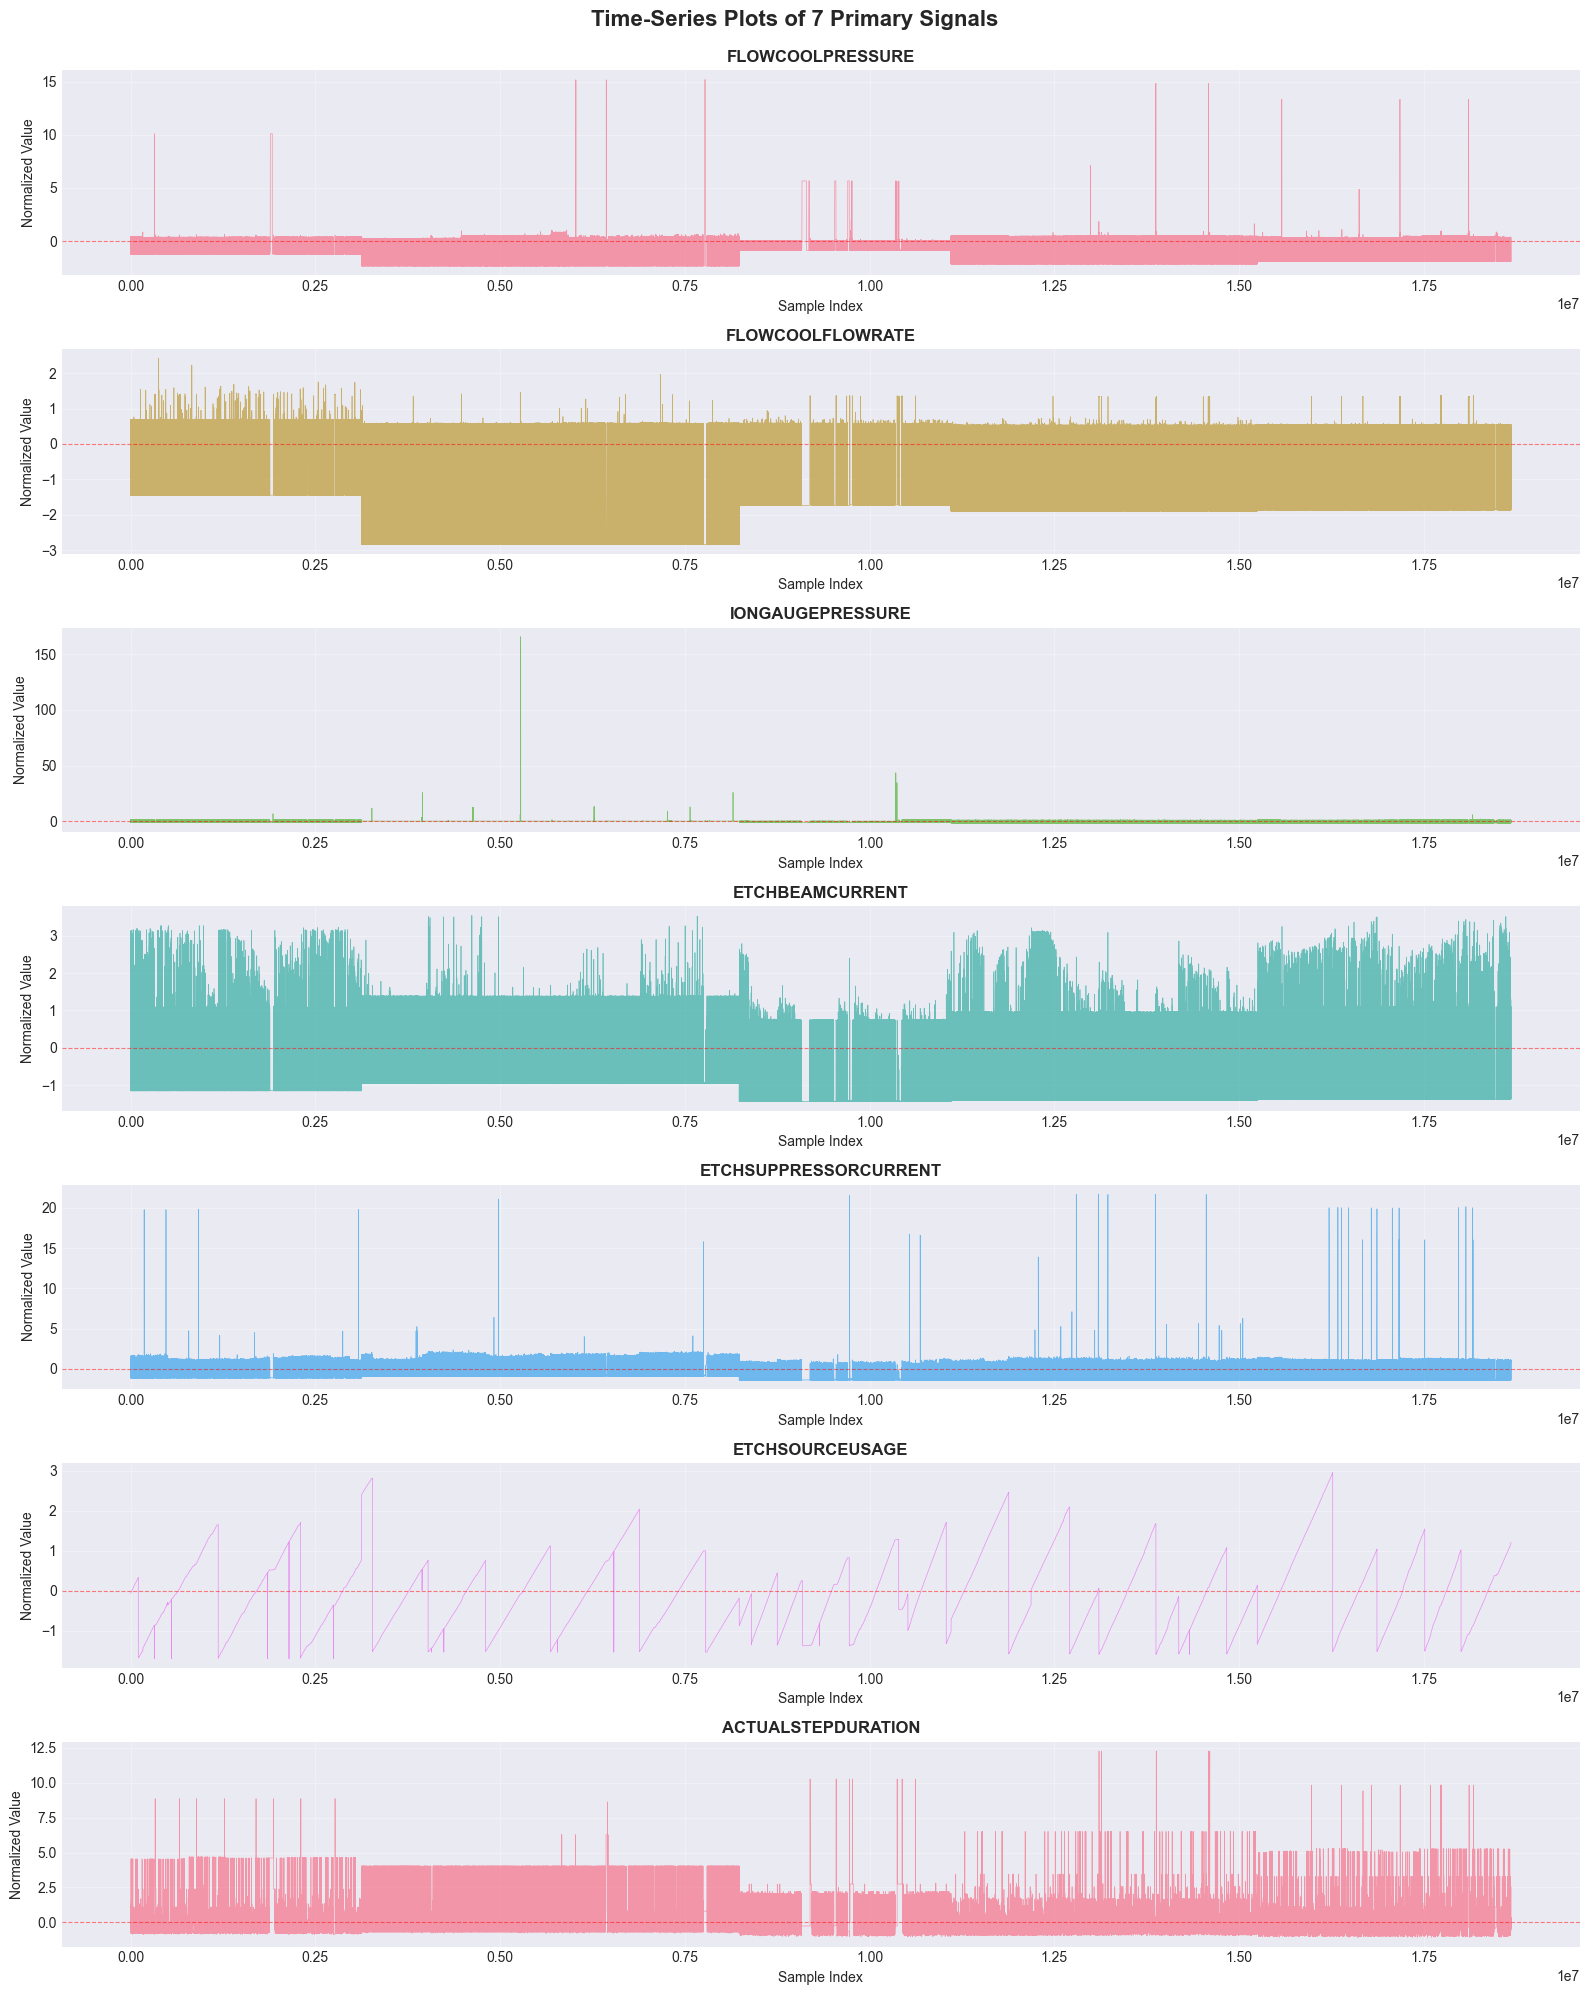

In [5]:
# Plot each signal as a time-series
fig, axes = plt.subplots(7, 1, figsize=(16, 20))
fig.suptitle('Time-Series Plots of 7 Primary Signals', fontsize=16, fontweight='bold', y=0.995)

# Use a subset for visualization (to avoid overcrowding)
plot_data = signals_df.iloc[::10]  # Every 10th sample

for idx, signal in enumerate(PRIMARY_SIGNALS):
    ax = axes[idx]
    ax.plot(plot_data.index, plot_data[signal], linewidth=0.5, alpha=0.7, color=f'C{idx}')
    ax.set_title(f'{signal}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index', fontsize=10)
    ax.set_ylabel('Normalized Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## 1.3 Statistical Summary

Computing key statistics for each signal: min, max, mean, median, std, percentiles, skewness, kurtosis.

In [6]:
# Compute statistics for each signal
stats_data = []

for signal in PRIMARY_SIGNALS:
    data = signals_df[signal].dropna()
    
    stats_row = {
        'Signal': signal,
        'Min': data.min(),
        'Max': data.max(),
        'Mean': data.mean(),
        'Median': data.median(),
        'Std Dev': data.std(),
        'P25': data.quantile(0.25),
        'P75': data.quantile(0.75),
        'P95': data.quantile(0.95),
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data),
    }
    stats_data.append(stats_row)

stats_summary = pd.DataFrame(stats_data)
print("\n" + "="*80)
print("STATISTICAL SUMMARY OF 7 PRIMARY SIGNALS")
print("="*80)
print(stats_summary.to_string(index=False))
print("="*80)

# Display as styled table
stats_summary.style.format({
    'Min': '{:.4f}',
    'Max': '{:.4f}',
    'Mean': '{:.4f}',
    'Median': '{:.4f}',
    'Std Dev': '{:.4f}',
    'P25': '{:.4f}',
    'P75': '{:.4f}',
    'P95': '{:.4f}',
    'Skewness': '{:.4f}',
    'Kurtosis': '{:.4f}',
}).background_gradient(cmap='coolwarm', subset=['Mean', 'Std Dev'])


STATISTICAL SUMMARY OF 7 PRIMARY SIGNALS
               Signal       Min        Max      Mean    Median  Std Dev       P25      P75      P95  Skewness    Kurtosis
     FLOWCOOLPRESSURE -2.333018  15.163873  0.038472  0.287067 1.123227 -0.006142 0.433822 0.492234  4.947578   59.404372
     FLOWCOOLFLOWRATE -2.842907   2.673885 -0.018684  0.536163 1.011175 -0.286919 0.571069 0.687388 -1.357855    0.331007
     IONGAUGEPRESSURE -1.762732 165.660246 -0.037332  0.016354 1.078864 -0.149248 0.670282 0.964064 58.616960 8980.369645
      ETCHBEAMCURRENT -1.443753   3.645582 -0.010659  0.068064 1.003040 -0.959651 0.937897 1.371548 -0.185467   -1.572439
ETCHSUPPRESSORCURRENT -1.416447  22.611466 -0.003632  0.217689 1.009845 -0.939043 0.866426 1.382203  0.004575    1.364494
      ETCHSOURCEUSAGE -1.700734   2.949560 -0.068639 -0.184311 0.961329 -0.841117 0.575364 1.649358  0.563578   -0.205031
   ACTUALSTEPDURATION -1.065014  12.266741  0.010144 -0.257227 1.024940 -0.620616 0.230690 1.660246  3.3

,Signal,Min,Max,Mean,Median,Std Dev,P25,P75,P95,Skewness,Kurtosis
0,FLOWCOOLPRESSURE,-2.3330,15.1639,0.0385,0.2871,1.1232,-0.0061,0.4338,0.4922,4.9476,59.4044
1,FLOWCOOLFLOWRATE,-2.8429,2.6739,-0.0187,0.5362,1.0112,-0.2869,0.5711,0.6874,-1.3579,0.3310
2,IONGAUGEPRESSURE,-1.7627,165.6602,-0.0373,0.0164,1.0789,-0.1492,0.6703,0.9641,58.6170,8980.3696
3,ETCHBEAMCURRENT,-1.4438,3.6456,-0.0107,0.0681,1.0030,-0.9597,0.9379,1.3715,-0.1855,-1.5724
4,ETCHSUPPRESSORCURRENT,-1.4164,22.6115,-0.0036,0.2177,1.0098,-0.9390,0.8664,1.3822,0.0046,1.3645
5,ETCHSOURCEUSAGE,-1.7007,2.9496,-0.0686,-0.1843,0.9613,-0.8411,0.5754,1.6494,0.5636,-0.2050
6,ACTUALSTEPDURATION,-1.0650,12.2667,0.0101,-0.2572,1.0249,-0.6206,0.2307,1.6602,3.3394,17.2604


## 1.4 Distribution Analysis

Visualizing the distribution of each signal using histograms and KDE plots.

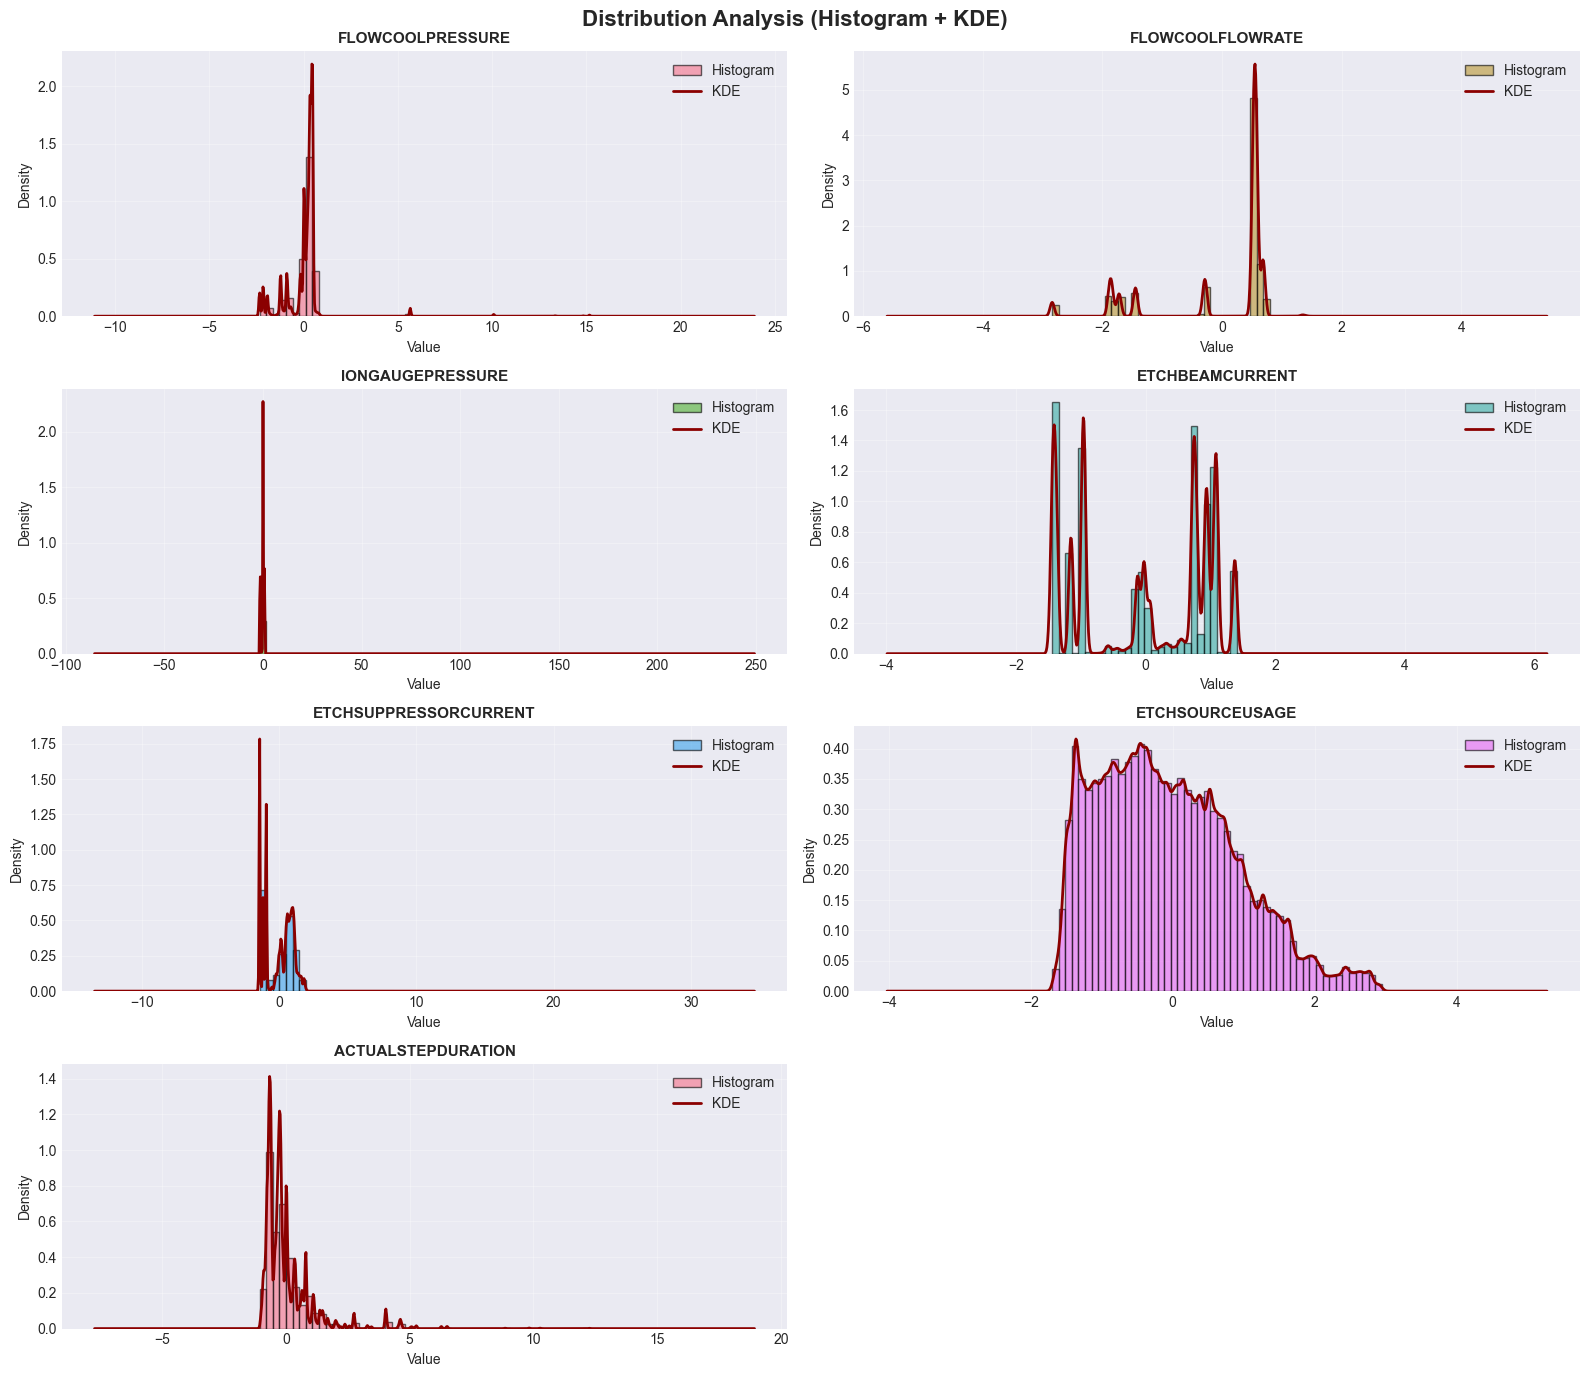

In [7]:
# Distribution plots (Histogram + KDE)
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
fig.suptitle('Distribution Analysis (Histogram + KDE)', fontsize=16, fontweight='bold')

for idx, signal in enumerate(PRIMARY_SIGNALS):
    ax = axes[idx]
    data = signals_df[signal].dropna()
    
    # Histogram
    ax.hist(data, bins=50, alpha=0.6, color=f'C{idx}', edgecolor='black', density=True, label='Histogram')
    
    # KDE
    data.plot.kde(ax=ax, linewidth=2, color='darkred', label='KDE')
    
    ax.set_title(f'{signal}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the last empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## 1.5 Rolling Statistics

Computing rolling mean and standard deviation to observe trends and volatility.

Analyzing machine: 01_M01
Samples: 3124704


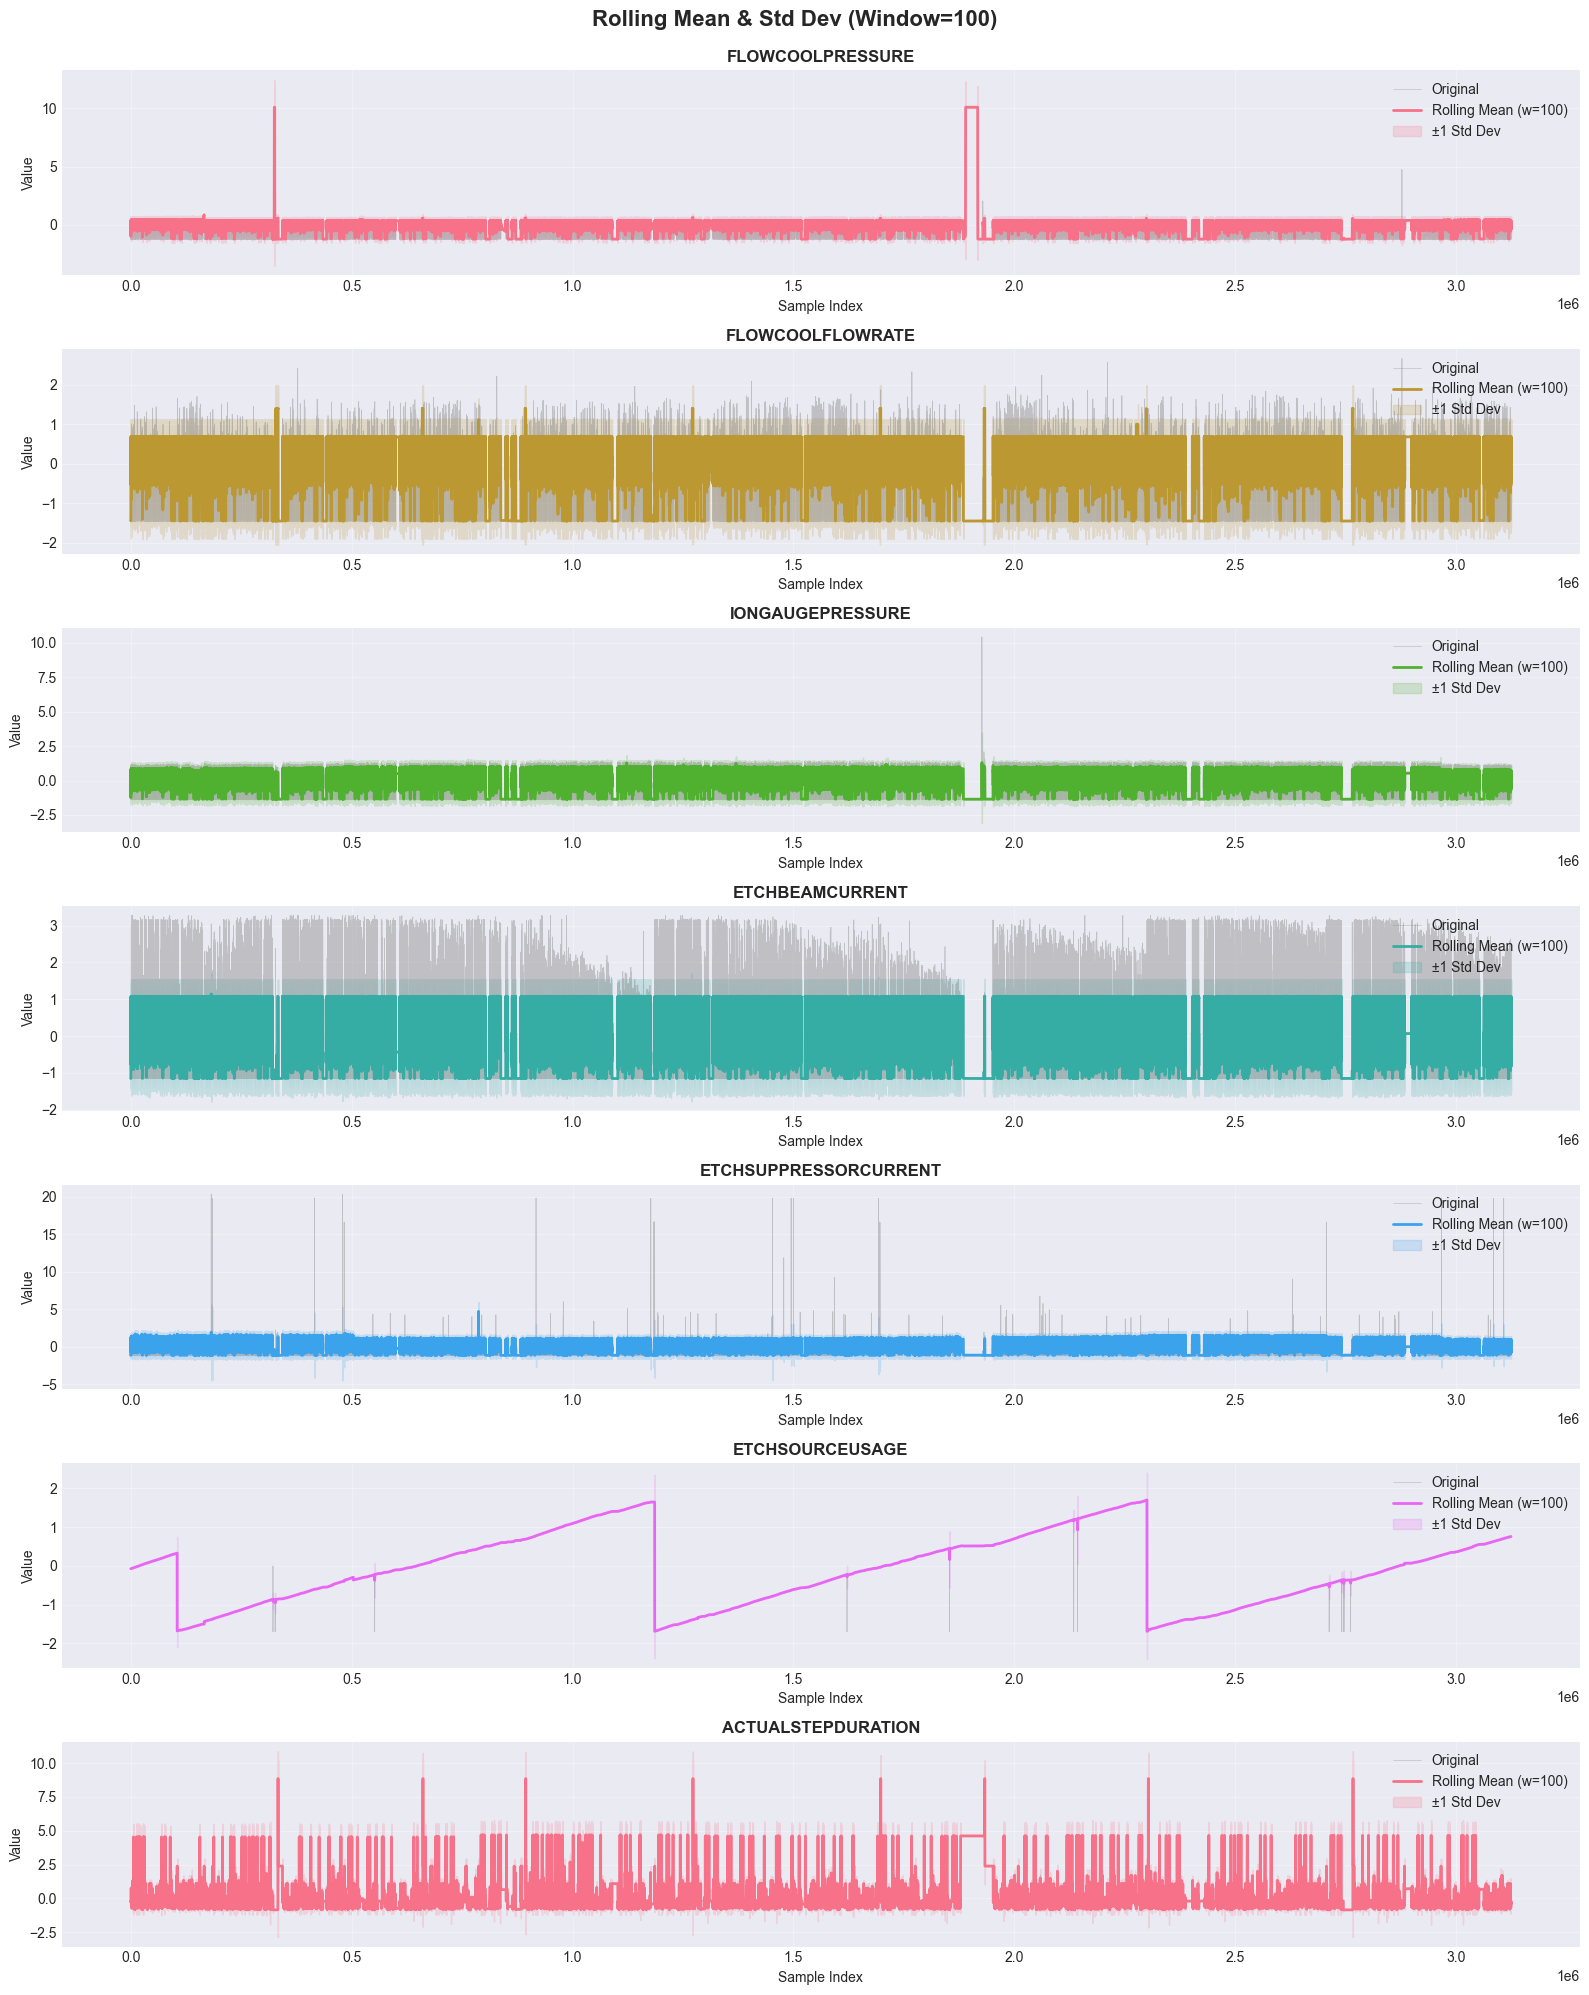

In [8]:
# Select one machine for detailed rolling analysis
sample_machine = signals_df[signals_df['machine_id'] == signals_df['machine_id'].unique()[0]].copy()
sample_machine = sample_machine.reset_index(drop=True)

print(f"Analyzing machine: {sample_machine['machine_id'].iloc[0]}")
print(f"Samples: {len(sample_machine)}")

# Rolling statistics
window = 100  # rolling window size

fig, axes = plt.subplots(7, 1, figsize=(16, 20))
fig.suptitle(f'Rolling Mean & Std Dev (Window={window})', fontsize=16, fontweight='bold', y=0.995)

for idx, signal in enumerate(PRIMARY_SIGNALS):
    ax = axes[idx]
    data = sample_machine[signal]
    
    # Original signal
    ax.plot(data.index, data, linewidth=0.5, alpha=0.4, color='gray', label='Original')
    
    # Rolling mean
    rolling_mean = data.rolling(window=window, min_periods=1).mean()
    ax.plot(rolling_mean.index, rolling_mean, linewidth=2, color=f'C{idx}', label=f'Rolling Mean (w={window})')
    
    # Rolling std (as shaded region)
    rolling_std = data.rolling(window=window, min_periods=1).std()
    ax.fill_between(rolling_mean.index,
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     alpha=0.2, color=f'C{idx}', label='±1 Std Dev')
    
    ax.set_title(f'{signal}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.6 Spike Detection

Identifying anomalous spikes using z-score threshold (z > 3).

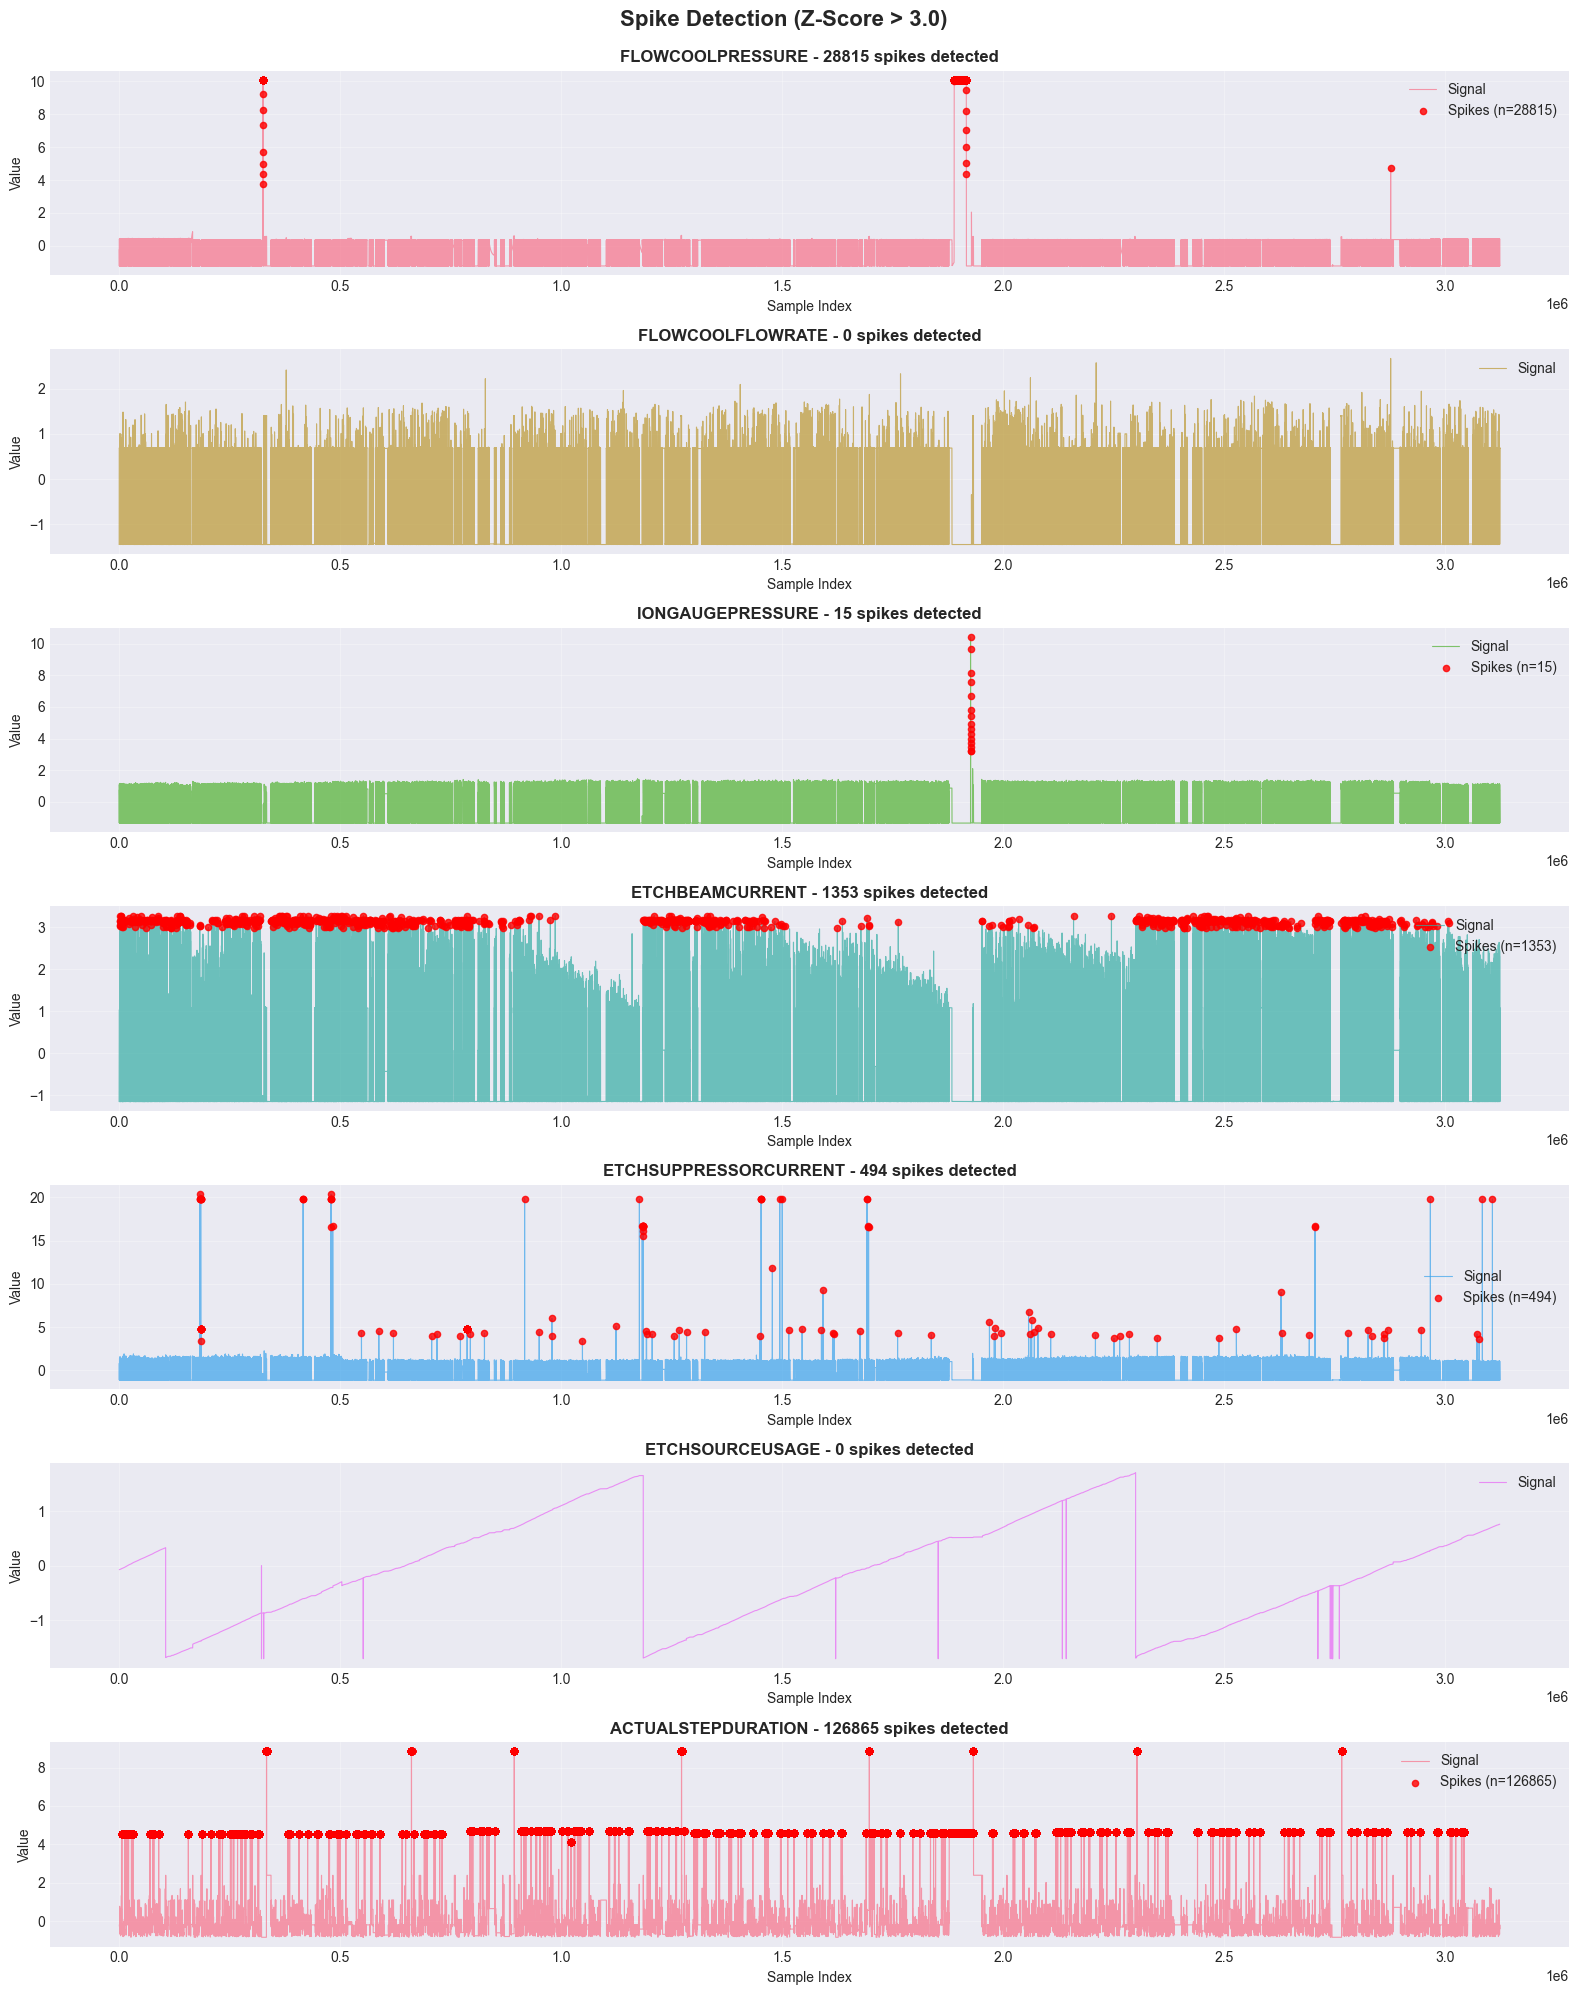


Spike Detection Summary:
               Signal  Total Samples  Spikes Detected  Spike Rate (%)
     FLOWCOOLPRESSURE        3124704            28815        0.922167
     FLOWCOOLFLOWRATE        3124704                0        0.000000
     IONGAUGEPRESSURE        3124704               15        0.000480
      ETCHBEAMCURRENT        3124704             1353        0.043300
ETCHSUPPRESSORCURRENT        3124704              494        0.015809
      ETCHSOURCEUSAGE        3124704                0        0.000000
   ACTUALSTEPDURATION        3124704           126865        4.060065


In [9]:
# Spike detection using z-score
z_threshold = 3.0
spike_summary = []

fig, axes = plt.subplots(7, 1, figsize=(16, 20))
fig.suptitle(f'Spike Detection (Z-Score > {z_threshold})', fontsize=16, fontweight='bold', y=0.995)

for idx, signal in enumerate(PRIMARY_SIGNALS):
    ax = axes[idx]
    data = sample_machine[signal]
    
    # Compute z-scores
    z_scores = np.abs(stats.zscore(data, nan_policy='omit'))
    spike_indices = np.where(z_scores > z_threshold)[0]
    
    # Plot signal
    ax.plot(data.index, data, linewidth=0.8, alpha=0.7, color=f'C{idx}', label='Signal')
    
    # Highlight spikes
    if len(spike_indices) > 0:
        ax.scatter(spike_indices, data.iloc[spike_indices], 
                   color='red', s=20, zorder=5, alpha=0.8, label=f'Spikes (n={len(spike_indices)})')
    
    ax.set_title(f'{signal} - {len(spike_indices)} spikes detected', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    spike_summary.append({
        'Signal': signal,
        'Total Samples': len(data),
        'Spikes Detected': len(spike_indices),
        'Spike Rate (%)': (len(spike_indices) / len(data)) * 100
    })

plt.tight_layout()
plt.show()

# Summary table
spike_df = pd.DataFrame(spike_summary)
print("\nSpike Detection Summary:")
print(spike_df.to_string(index=False))

## 1.7 Correlation Analysis

Computing and visualizing correlations between all 7 signals.

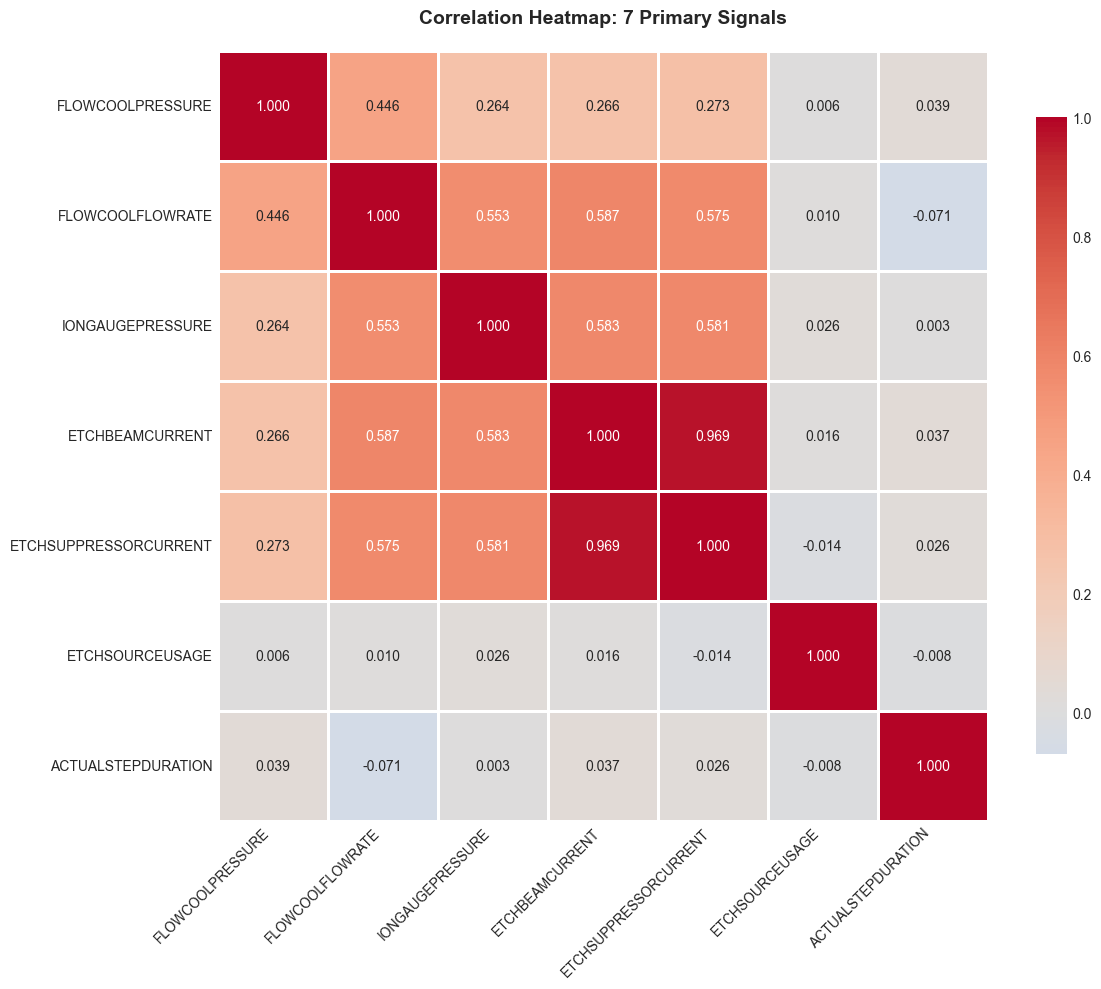


Highly Correlated Signal Pairs (|correlation| > 0.7):


In [10]:
# Correlation matrix
corr_matrix = signals_df[PRIMARY_SIGNALS].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: 7 Primary Signals', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find highly correlated pairs
print("\nHighly Correlated Signal Pairs (|correlation| > 0.7):")
high_corr = []
for i in range(len(PRIMARY_SIGNALS)):
    for j in range(i+1, len(PRIMARY_SIGNALS)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr.append({
                'Signal 1': PRIMARY_SIGNALS[i],
                'Signal 2': PRIMARY_SIGNALS[j],
                'Correlation': corr_val
            })

if high_corr:
    pd.DataFrame(high_corr).sort_values('Correlation', ascending=False)
else:
    print("No signal pairs with |correlation| > 0.7")

---
# Part 2: Post-Enforcement Signal Analysis

This section analyzes the signals after enforcement (attenuation) to evaluate effectiveness.

## 2.1 Load Enforcement Results

In [11]:
# Cell 2.1 - Load Enforcement Results
# Define the EnforcementResult class (must match the original definition)
from dataclasses import dataclass
from typing import Dict, Any

@dataclass
class EnforcementResult:
    """Result object from enforcement analysis"""
    machine_id: str
    window_idx: int
    alarm_segment: int
    true_label: int
    signals: Dict[str, Dict[str, Any]]

# Load enforcement results
print("Loading enforcement results...")
try:
    enforcement_results = joblib.load(ENFORCER_RESULTS_PATH)
    print(f"Loaded {len(enforcement_results)} enforcement events")
except FileNotFoundError:
    print(f"Error: File not found at {ENFORCER_RESULTS_PATH}")
    enforcement_results = []

# Load JSON report
try:
    with open(ENFORCER_REPORT_PATH, 'r') as f:
        enforcement_report = json.load(f)
    print(f"JSON report contains {len(enforcement_report)} events")
except FileNotFoundError:
    print(f"Error: File not found at {ENFORCER_REPORT_PATH}")
    enforcement_report = []

# Summary statistics
if len(enforcement_results) > 0:
    tp_count = sum(1 for r in enforcement_results if r.true_label == 1)
    fp_count = sum(1 for r in enforcement_results if r.true_label == 0)

    print(f"\nEnforcement Summary:")
    print(f"  True Positives (TP):  {tp_count}")
    print(f"  False Positives (FP): {fp_count}")
    print(f"  Total Events:         {len(enforcement_results)}")
else:
    print("\nWarning: No enforcement results loaded")

Loading enforcement results...
Loaded 4170 enforcement events
JSON report contains 4170 events

Enforcement Summary:
  True Positives (TP):  102
  False Positives (FP): 4068
  Total Events:         4170


## 2.2 Enforcement Metrics Overview

In [12]:
# Create summary DataFrame from JSON report
summary_data = []
for event in enforcement_report:
    summary_data.append({
        'machine_id': event['machine_id'],
        'window_idx': event['window_idx'],
        'alarm_segment': event['alarm_segment'],
        'label': 'TP' if event['true_label'] == 1 else 'FP',
        'n_spikes_detected': event['n_spikes_detected'],
        'peak_attenuation': event['peak_attenuation'],
        'enforcement_duration_s': event['enforcement_duration_seconds'],
        'total_delta': event['counterfactual_total_delta'],
    })

summary_df = pd.DataFrame(summary_data)
print("\nEnforcement Metrics Overview:")
print(summary_df.head(10))

# Statistical summary
print("\n" + "="*80)
print("ENFORCEMENT METRICS STATISTICS")
print("="*80)
print(summary_df.describe())
print("="*80)


Enforcement Metrics Overview:
  machine_id  window_idx  alarm_segment label  n_spikes_detected  \
0     01_M01           0              0    FP               1020   
1     01_M01           1              3    FP                742   
2     01_M01           2              0    FP                952   
3     01_M01           3              0    FP                961   
4     01_M01           4              4    FP                501   
5     01_M01           5              3    FP                728   
6     01_M01           6              0    FP                347   
7     01_M01           7              0    FP                418   
8     01_M01           8              0    FP                880   
9     01_M01           9              3    FP                898   

   peak_attenuation  enforcement_duration_s  total_delta  
0          0.088125                  9720.0   10404.6425  
1          0.198097                  6480.0    5471.3557  
2          0.088125                  9720.0

## 2.3 Original vs Attenuated Signal Comparison

Visualizing selected events showing original and enforced signals side-by-side.


Visualizing True Positive Event:
  Machine: 01_M01, Window: 63, Alarm Segment: 0


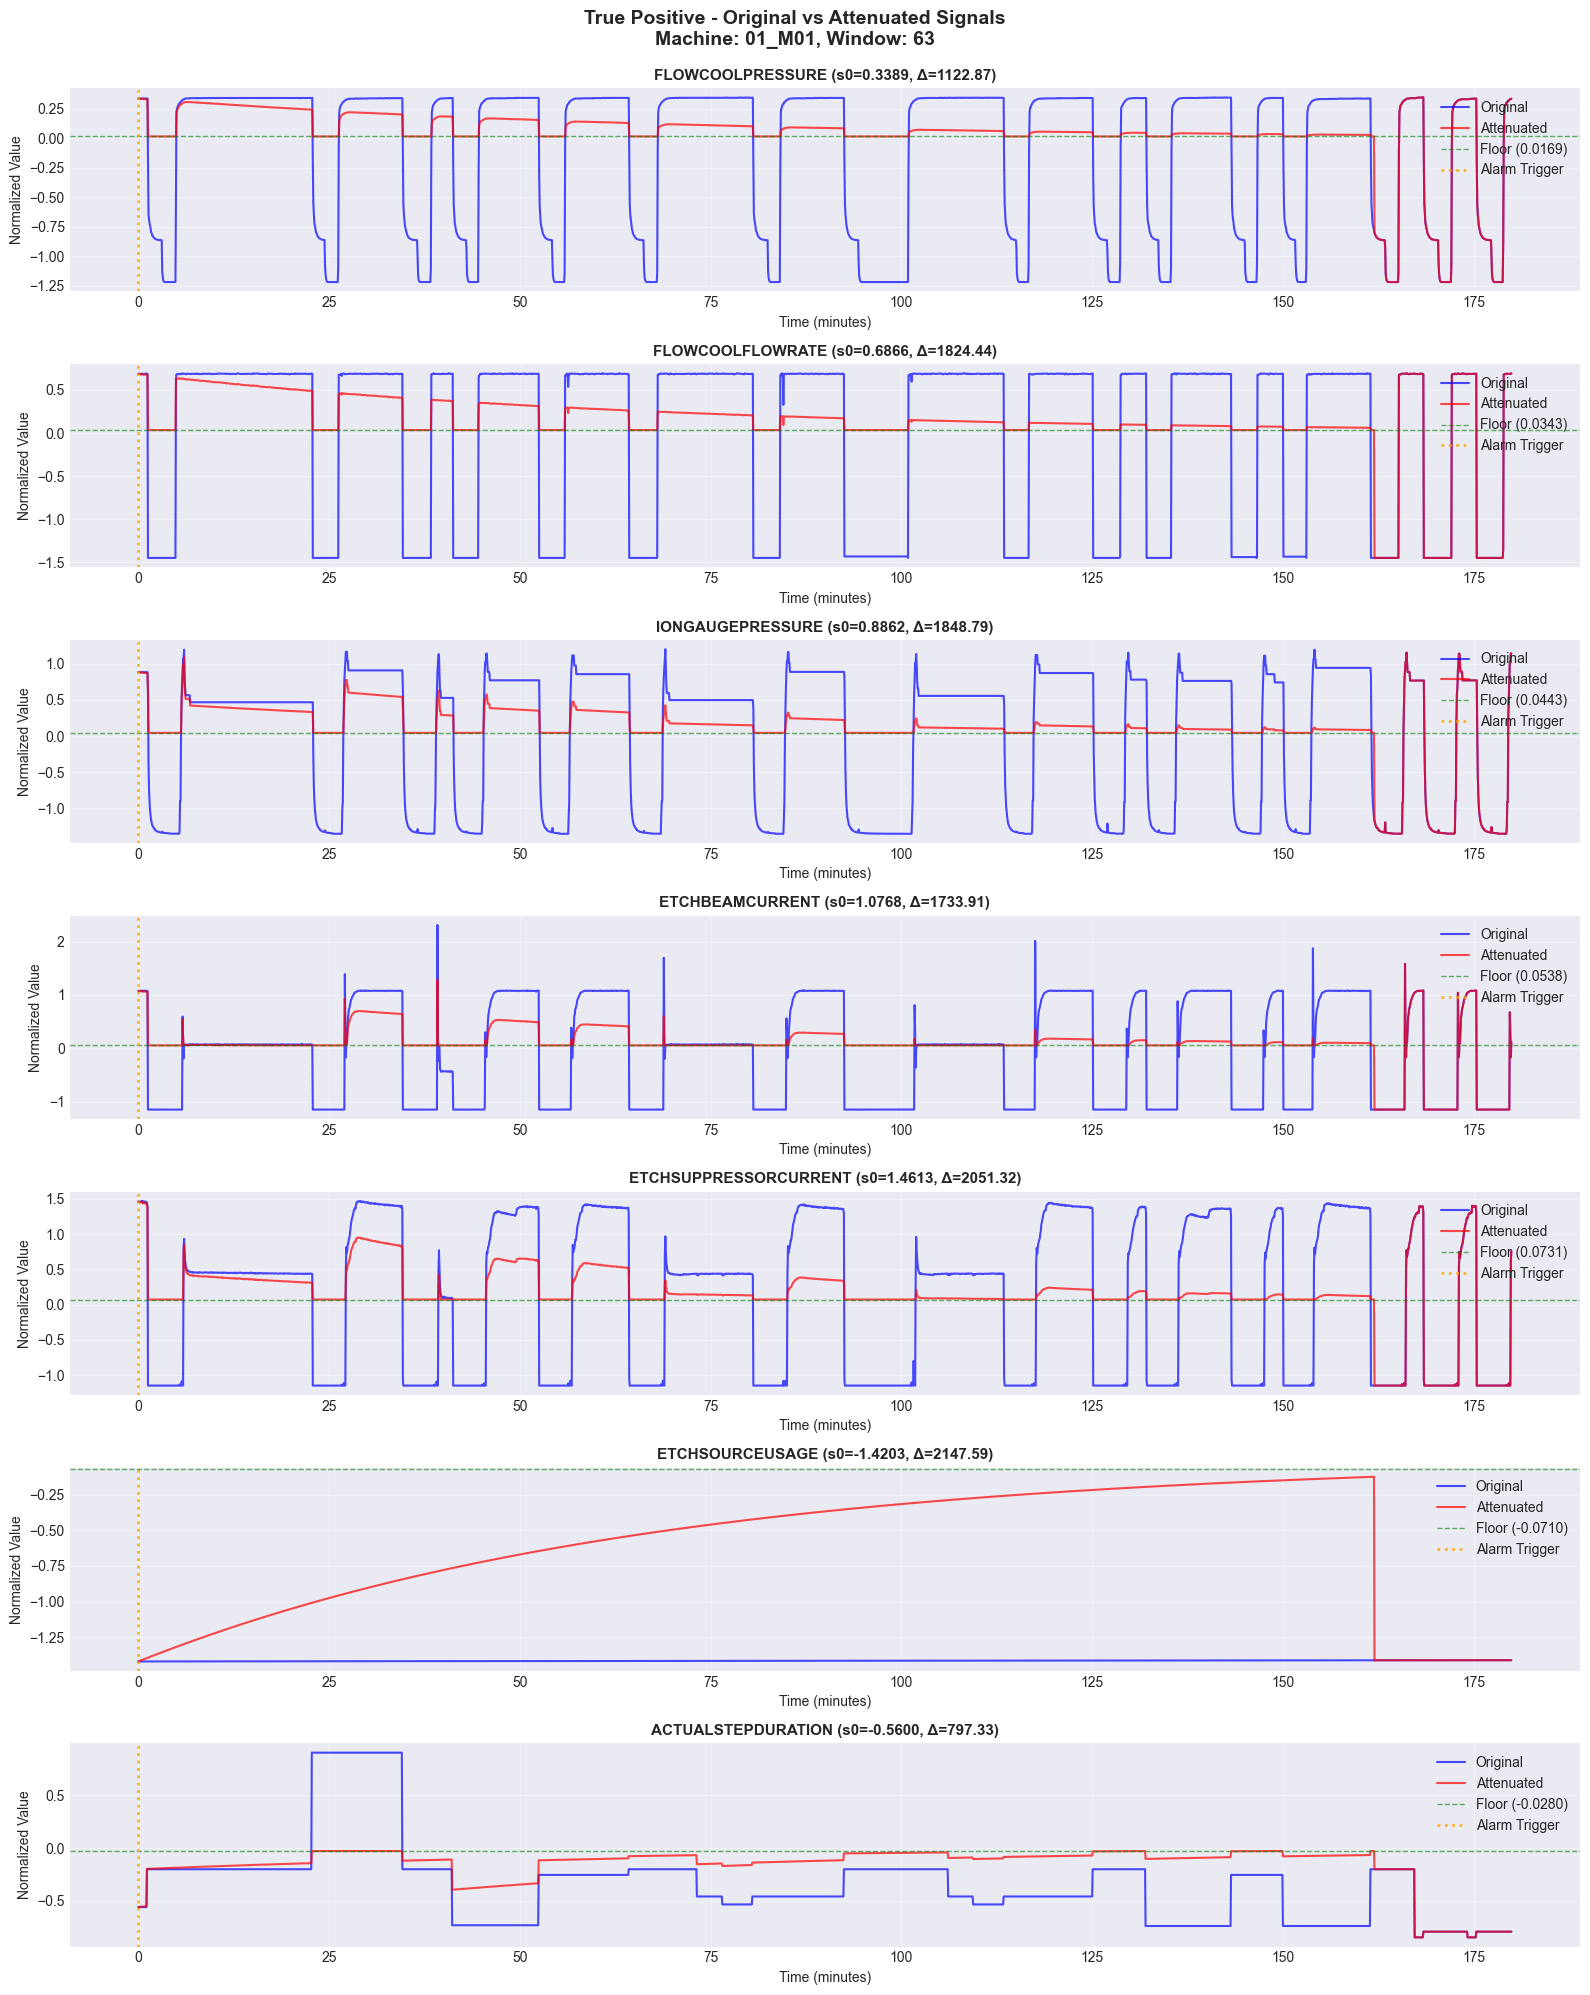


Visualizing False Positive Event:
  Machine: 01_M01, Window: 0, Alarm Segment: 0


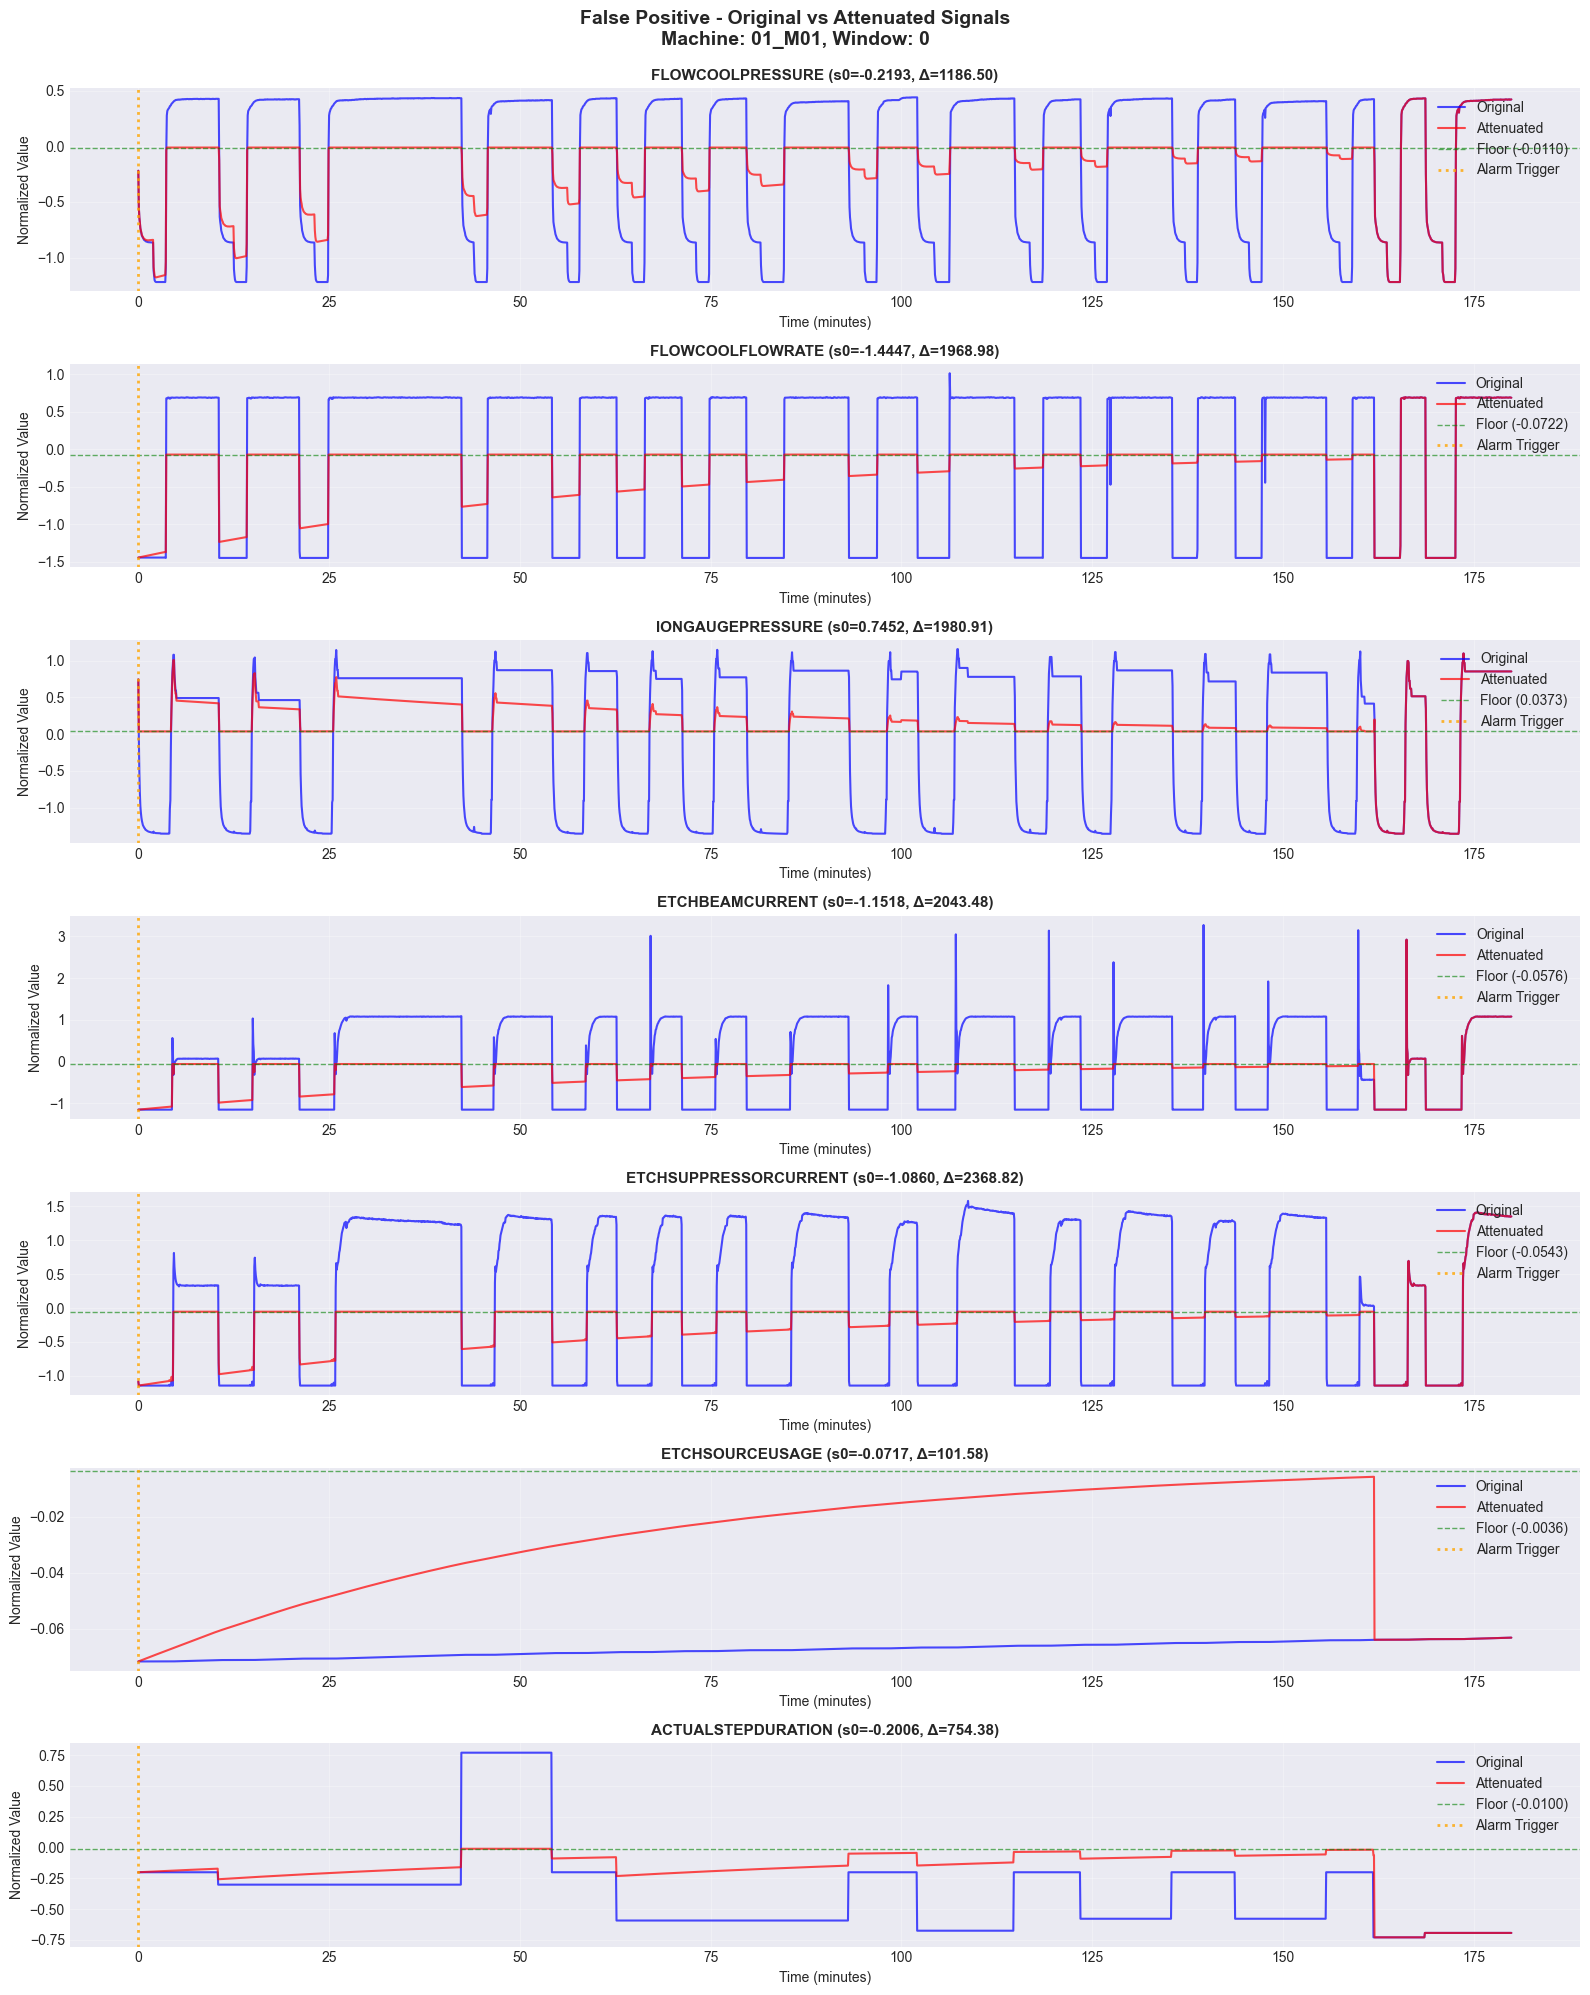

In [13]:
# Select a few representative events to visualize
# Get one TP and one FP event
tp_events = [r for r in enforcement_results if r.true_label == 1]
fp_events = [r for r in enforcement_results if r.true_label == 0]

sample_events = []
if tp_events:
    sample_events.append(('True Positive', tp_events[0]))
if fp_events:
    sample_events.append(('False Positive', fp_events[0]))

# Plot for each sample event
for event_type, result in sample_events:
    print(f"\nVisualizing {event_type} Event:")
    print(f"  Machine: {result.machine_id}, Window: {result.window_idx}, Alarm Segment: {result.alarm_segment}")
    
    fig, axes = plt.subplots(7, 1, figsize=(16, 20))
    fig.suptitle(f'{event_type} - Original vs Attenuated Signals\n' + 
                 f'Machine: {result.machine_id}, Window: {result.window_idx}',
                 fontsize=14, fontweight='bold', y=0.995)
    
    for idx, signal in enumerate(PRIMARY_SIGNALS):
        if signal not in result.signals:
            continue
        
        ax = axes[idx]
        signal_data = result.signals[signal]
        
        # Get original and enforced signals
        original = signal_data.get('original', np.array([]))
        enforced = signal_data.get('enforced', np.array([]))
        
        if len(original) == 0 or len(enforced) == 0:
            continue
        
        # Plot both signals
        time_axis = np.arange(len(original)) * SAMPLING_RATE / 60  # convert to minutes
        
        ax.plot(time_axis, original, linewidth=1.5, alpha=0.7, color='blue', label='Original')
        ax.plot(time_axis, enforced, linewidth=1.5, alpha=0.7, color='red', label='Attenuated')
        
        # Mark enforcement floor
        floor_value = signal_data.get('floor_value', 0)
        s0 = signal_data.get('s0', 0)
        if s0 >= 0:
            ax.axhline(y=floor_value, color='green', linestyle='--', linewidth=1, 
                      alpha=0.6, label=f'Floor ({floor_value:.4f})')
        else:
            ax.axhline(y=-floor_value, color='green', linestyle='--', linewidth=1, 
                      alpha=0.6, label=f'Floor ({-floor_value:.4f})')
        
        # Mark alarm trigger point
        alarm_sample = result.alarm_segment * (len(original) // 10)  # approximate
        alarm_time = alarm_sample * SAMPLING_RATE / 60
        ax.axvline(x=alarm_time, color='orange', linestyle=':', linewidth=2, 
                  alpha=0.8, label='Alarm Trigger')
        
        ax.set_title(f'{signal} (s0={s0:.4f}, Δ={signal_data.get("counterfactual_delta", 0):.2f})', 
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Time (minutes)', fontsize=10)
        ax.set_ylabel('Normalized Value', fontsize=10)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 2.4 Comparative Metrics Analysis

Computing and comparing metrics before vs after attenuation.

In [14]:
# Compute comparative metrics across all events
comparative_data = []

for result in enforcement_results[:100]:  # Analyze first 100 events
    for signal in PRIMARY_SIGNALS:
        if signal not in result.signals:
            continue
        
        signal_data = result.signals[signal]
        original = signal_data.get('original', np.array([]))
        enforced = signal_data.get('enforced', np.array([]))
        
        if len(original) == 0 or len(enforced) == 0:
            continue
        
        # Compute metrics
        orig_mean = np.mean(original)
        enf_mean = np.mean(enforced)
        orig_max = np.max(np.abs(original))
        enf_max = np.max(np.abs(enforced))
        orig_var = np.var(original)
        enf_var = np.var(enforced)
        
        # Count spikes (simple threshold-based)
        spike_threshold = 2.0
        orig_spikes = np.sum(np.abs(original) > spike_threshold)
        enf_spikes = np.sum(np.abs(enforced) > spike_threshold)
        
        comparative_data.append({
            'machine_id': result.machine_id,
            'window_idx': result.window_idx,
            'label': 'TP' if result.true_label == 1 else 'FP',
            'signal': signal,
            'mean_change': enf_mean - orig_mean,
            'max_change': enf_max - orig_max,
            'var_change': enf_var - orig_var,
            'spike_reduction': orig_spikes - enf_spikes,
            'spike_reduction_pct': ((orig_spikes - enf_spikes) / max(orig_spikes, 1)) * 100,
            'attenuation_delta': signal_data.get('counterfactual_delta', 0),
        })

comp_df = pd.DataFrame(comparative_data)
print("\nComparative Metrics Summary:")
print(comp_df.head(20))

# Aggregate by signal
print("\n" + "="*80)
print("PER-SIGNAL AGGREGATE METRICS")
print("="*80)
signal_agg = comp_df.groupby('signal').agg({
    'mean_change': 'mean',
    'max_change': 'mean',
    'var_change': 'mean',
    'spike_reduction': 'sum',
    'spike_reduction_pct': 'mean',
    'attenuation_delta': 'mean',
}).round(4)
print(signal_agg)
print("="*80)


Comparative Metrics Summary:
   machine_id  window_idx label                 signal  mean_change  \
0      01_M01           0    FP       FLOWCOOLPRESSURE    -0.052068   
1      01_M01           0    FP       FLOWCOOLFLOWRATE    -0.166453   
2      01_M01           0    FP       IONGAUGEPRESSURE     0.199947   
3      01_M01           0    FP        ETCHBEAMCURRENT    -0.199178   
4      01_M01           0    FP  ETCHSUPPRESSORCURRENT    -0.311269   
5      01_M01           0    FP        ETCHSOURCEUSAGE     0.037620   
6      01_M01           0    FP     ACTUALSTEPDURATION     0.176580   
7      01_M01           1    FP       FLOWCOOLPRESSURE     0.014647   
8      01_M01           1    FP       FLOWCOOLFLOWRATE     0.000894   
9      01_M01           1    FP       IONGAUGEPRESSURE    -0.251656   
10     01_M01           1    FP        ETCHBEAMCURRENT    -0.219681   
11     01_M01           1    FP  ETCHSUPPRESSORCURRENT    -0.311512   
12     01_M01           1    FP        ETCHSOUR

## 2.5 Attenuation Magnitude Analysis

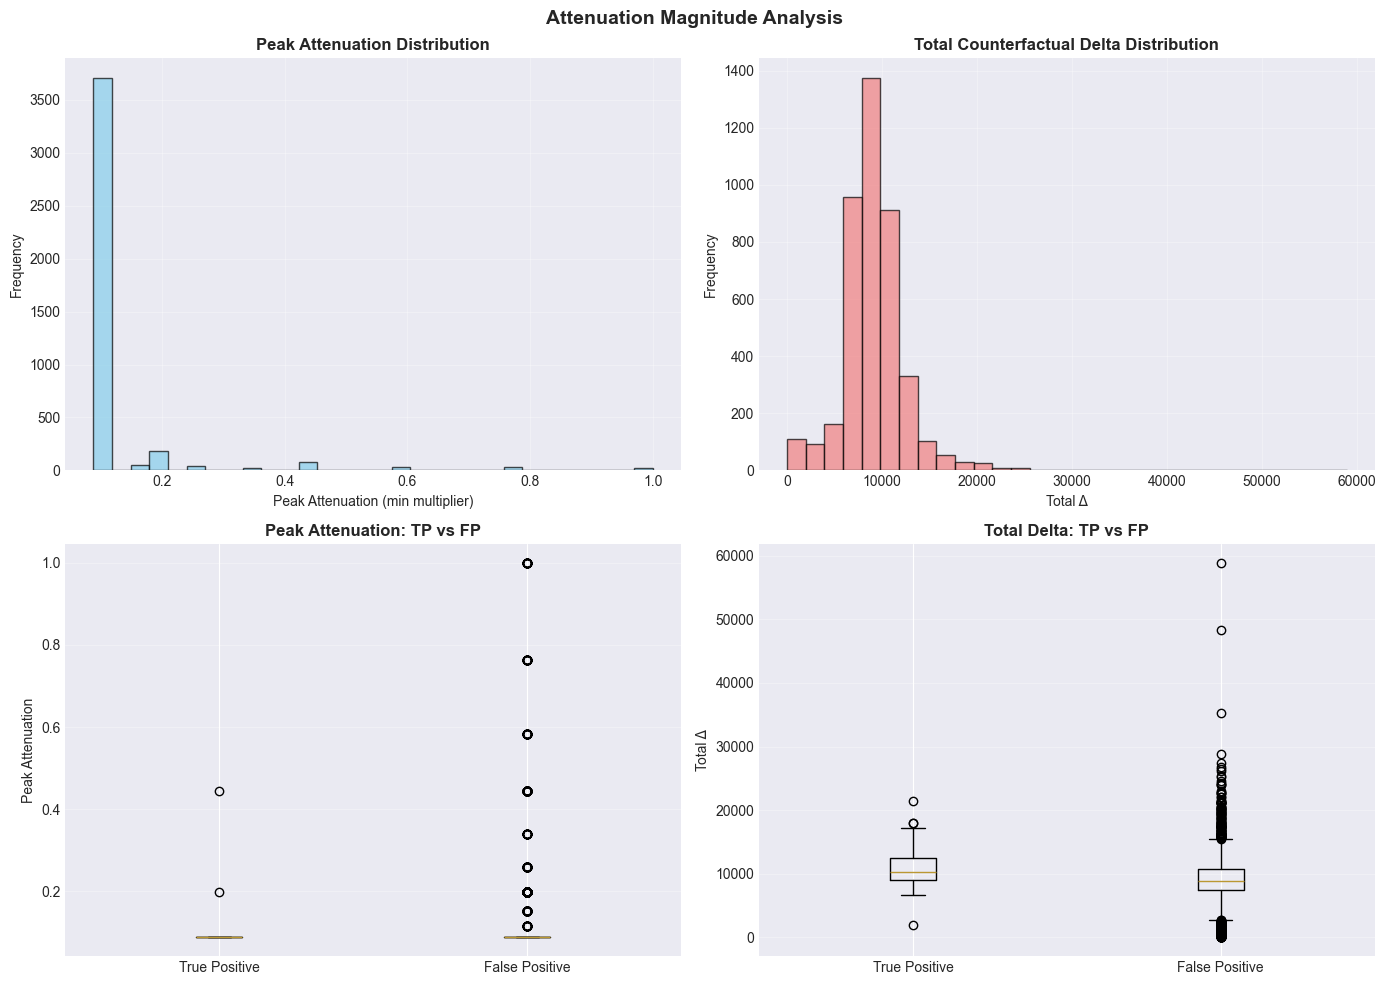

In [15]:
# Visualize attenuation magnitude distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Attenuation Magnitude Analysis', fontsize=14, fontweight='bold')

# Plot 1: Peak attenuation distribution
ax = axes[0, 0]
ax.hist(summary_df['peak_attenuation'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_title('Peak Attenuation Distribution', fontweight='bold')
ax.set_xlabel('Peak Attenuation (min multiplier)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# Plot 2: Total delta distribution
ax = axes[0, 1]
ax.hist(summary_df['total_delta'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
ax.set_title('Total Counterfactual Delta Distribution', fontweight='bold')
ax.set_xlabel('Total Δ')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# Plot 3: TP vs FP - Peak attenuation
ax = axes[1, 0]
tp_data = summary_df[summary_df['label'] == 'TP']['peak_attenuation']
fp_data = summary_df[summary_df['label'] == 'FP']['peak_attenuation']
ax.boxplot([tp_data, fp_data], labels=['True Positive', 'False Positive'])
ax.set_title('Peak Attenuation: TP vs FP', fontweight='bold')
ax.set_ylabel('Peak Attenuation')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: TP vs FP - Total delta
ax = axes[1, 1]
tp_delta = summary_df[summary_df['label'] == 'TP']['total_delta']
fp_delta = summary_df[summary_df['label'] == 'FP']['total_delta']
ax.boxplot([tp_delta, fp_delta], labels=['True Positive', 'False Positive'])
ax.set_title('Total Delta: TP vs FP', fontweight='bold')
ax.set_ylabel('Total Δ')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 2.6 Enforcement Effectiveness Analysis


ENFORCEMENT EFFECTIVENESS: TP vs FP

True Positive Events:
        window_idx  alarm_segment  n_spikes_detected  peak_attenuation  \
count   102.000000     102.000000         102.000000        102.000000   
mean   2514.235294       0.088235         500.009804          0.092705   
std    2008.257484       0.661575         225.412866          0.036901   
min      63.000000       0.000000          62.000000          0.088125   
25%    1208.500000       0.000000         368.000000          0.088125   
50%    2178.500000       0.000000         465.000000          0.088125   
75%    2849.750000       0.000000         603.000000          0.088125   
max    7670.000000       6.000000        1068.000000          0.445303   

       enforcement_duration_s   total_delta  
count              102.000000    102.000000  
mean              9624.705882  10996.082750  
std                714.501427   2982.730260  
min               3240.000000   1914.531300  
25%               9720.000000   9074.868225

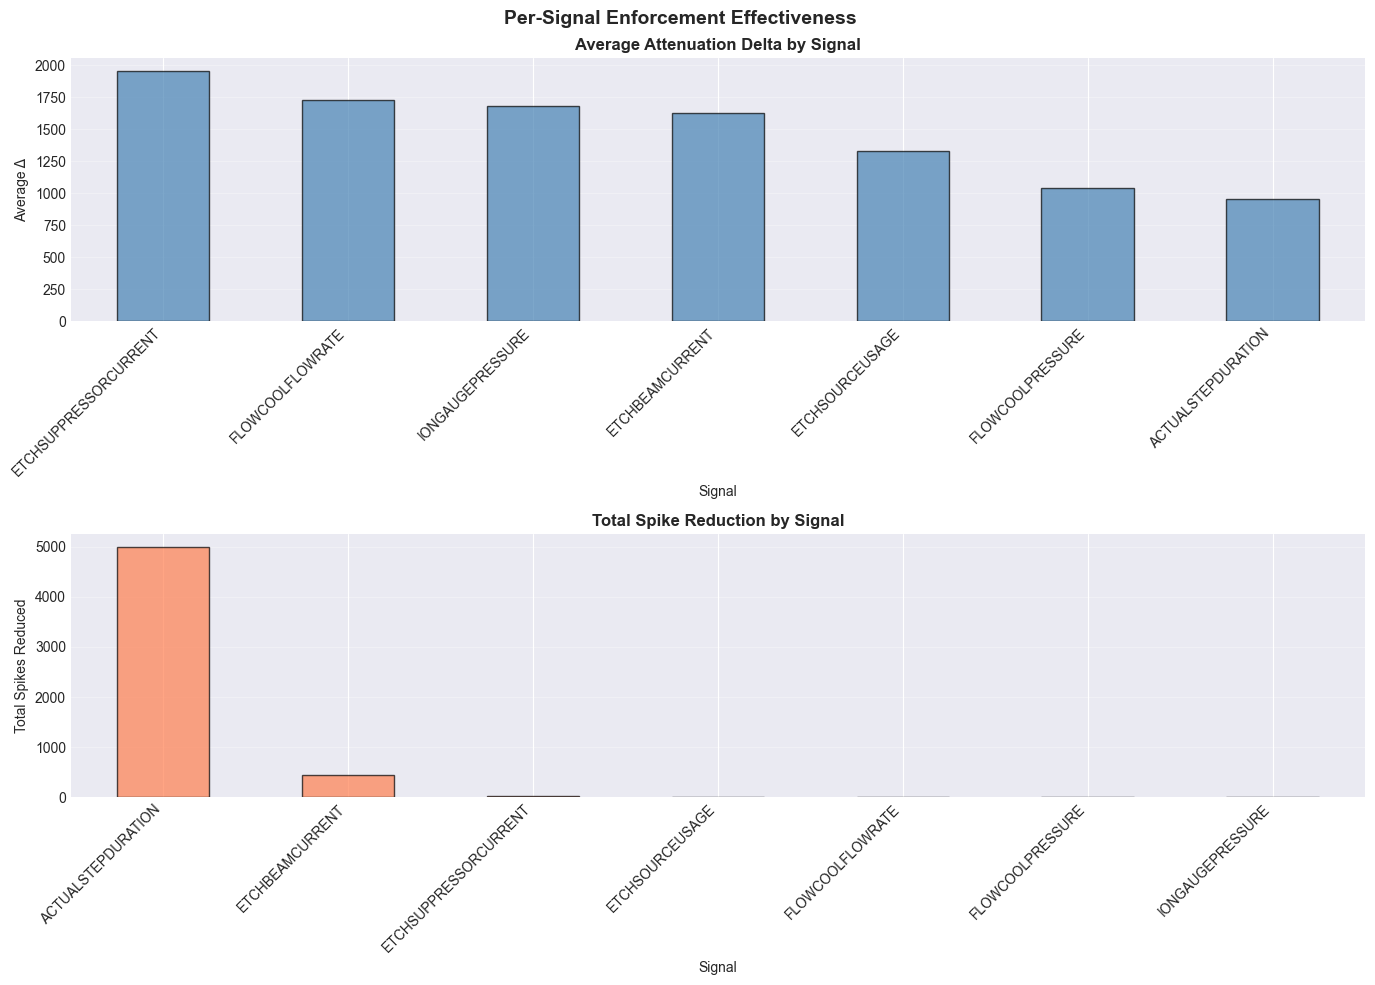

In [16]:
# Compare enforcement effectiveness for TP vs FP
print("\n" + "="*80)
print("ENFORCEMENT EFFECTIVENESS: TP vs FP")
print("="*80)

tp_summary = summary_df[summary_df['label'] == 'TP'].describe()
fp_summary = summary_df[summary_df['label'] == 'FP'].describe()

print("\nTrue Positive Events:")
print(tp_summary)
print("\nFalse Positive Events:")
print(fp_summary)
print("="*80)

# Visualize per-signal effectiveness
if len(comp_df) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Per-Signal Enforcement Effectiveness', fontsize=14, fontweight='bold')
    
    # Plot 1: Average attenuation delta by signal
    ax = axes[0]
    signal_delta = comp_df.groupby('signal')['attenuation_delta'].mean().sort_values(ascending=False)
    signal_delta.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title('Average Attenuation Delta by Signal', fontweight='bold')
    ax.set_xlabel('Signal')
    ax.set_ylabel('Average Δ')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Plot 2: Spike reduction by signal
    ax = axes[1]
    signal_spikes = comp_df.groupby('signal')['spike_reduction'].sum().sort_values(ascending=False)
    signal_spikes.plot(kind='bar', ax=ax, color='coral', alpha=0.7, edgecolor='black')
    ax.set_title('Total Spike Reduction by Signal', fontweight='bold')
    ax.set_xlabel('Signal')
    ax.set_ylabel('Total Spikes Reduced')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

## 2.7 Strong vs Weak Attenuation Cases


ATTENUATION STRENGTH DISTRIBUTION
attenuation_strength
Strong      4083
Moderate      60
Weak          27
Name: count, dtype: int64


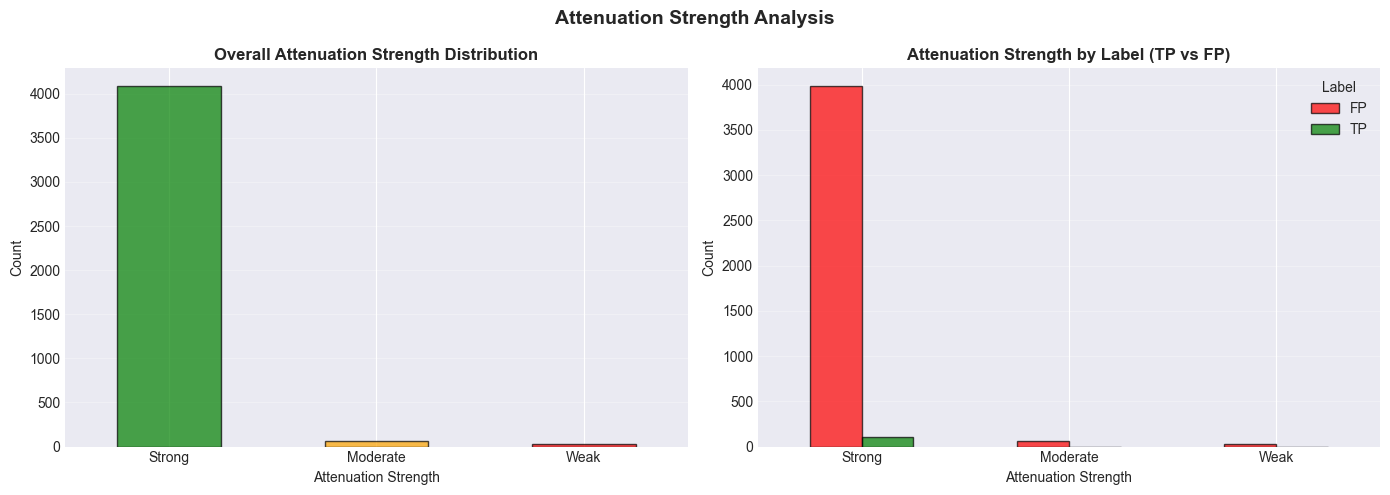

In [17]:
# Classify events into strong vs weak attenuation
# Strong: peak_attenuation < 0.5, Weak: peak_attenuation > 0.8
summary_df['attenuation_strength'] = pd.cut(
    summary_df['peak_attenuation'],
    bins=[0, 0.5, 0.8, 1.0],
    labels=['Strong', 'Moderate', 'Weak']
)

print("\n" + "="*80)
print("ATTENUATION STRENGTH DISTRIBUTION")
print("="*80)
strength_dist = summary_df['attenuation_strength'].value_counts()
print(strength_dist)
print("="*80)

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attenuation Strength Analysis', fontsize=14, fontweight='bold')

# Plot 1: Overall distribution
ax = axes[0]
strength_dist.plot(kind='bar', ax=ax, color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
ax.set_title('Overall Attenuation Strength Distribution', fontweight='bold')
ax.set_xlabel('Attenuation Strength')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: TP vs FP by strength
ax = axes[1]
strength_by_label = pd.crosstab(summary_df['attenuation_strength'], summary_df['label'])
strength_by_label.plot(kind='bar', ax=ax, color=['red', 'green'], alpha=0.7, edgecolor='black')
ax.set_title('Attenuation Strength by Label (TP vs FP)', fontweight='bold')
ax.set_xlabel('Attenuation Strength')
ax.set_ylabel('Count')
ax.legend(title='Label')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 2.8 Persistent Anomalies (Despite Enforcement)


Persistent Anomaly Cases (>100 spikes detected):
Found 3992 cases

  machine_id  window_idx label  n_spikes_detected  peak_attenuation  \
0     01_M01           0    FP               1020          0.088125   
1     01_M01           1    FP                742          0.198097   
2     01_M01           2    FP                952          0.088125   
3     01_M01           3    FP                961          0.088125   
4     01_M01           4    FP                501          0.259500   
5     01_M01           5    FP                728          0.198097   
6     01_M01           6    FP                347          0.088125   
7     01_M01           7    FP                418          0.088125   
8     01_M01           8    FP                880          0.088125   
9     01_M01           9    FP                898          0.198097   

   total_delta  
0   10404.6425  
1    5471.3557  
2   10444.1770  
3    9810.6120  
4    4143.8226  
5    5565.5346  
6    9505.5653  
7   12654.8020

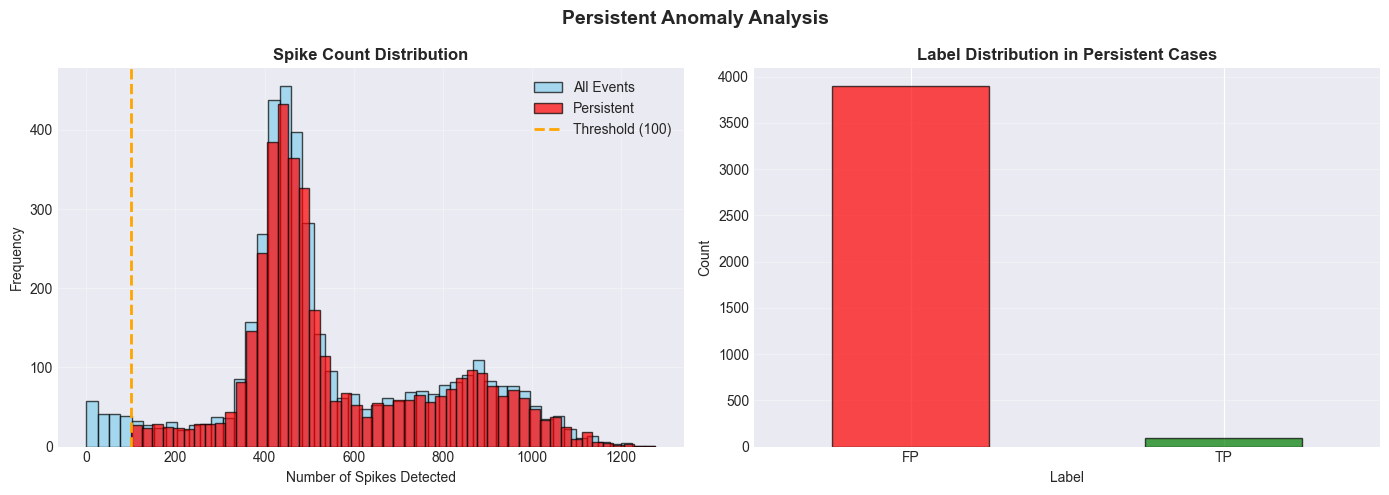

In [18]:
# Identify cases where anomalies persist despite enforcement
# Using spike count as a proxy for anomaly severity
persistent_threshold = 100  # Events with >100 spikes after enforcement

persistent_cases = summary_df[summary_df['n_spikes_detected'] > persistent_threshold].copy()

print(f"\nPersistent Anomaly Cases (>{persistent_threshold} spikes detected):")
print(f"Found {len(persistent_cases)} cases\n")

if len(persistent_cases) > 0:
    print(persistent_cases[['machine_id', 'window_idx', 'label', 
                            'n_spikes_detected', 'peak_attenuation', 'total_delta']].head(10))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Persistent Anomaly Analysis', fontsize=14, fontweight='bold')
    
    # Plot 1: Spike count distribution
    ax = axes[0]
    ax.hist(summary_df['n_spikes_detected'], bins=50, alpha=0.7, color='skyblue', edgecolor='black', label='All Events')
    ax.hist(persistent_cases['n_spikes_detected'], bins=50, alpha=0.7, color='red', edgecolor='black', label='Persistent')
    ax.axvline(x=persistent_threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold ({persistent_threshold})')
    ax.set_title('Spike Count Distribution', fontweight='bold')
    ax.set_xlabel('Number of Spikes Detected')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: TP vs FP in persistent cases
    ax = axes[1]
    if len(persistent_cases) > 0:
        persistent_label_dist = persistent_cases['label'].value_counts()
        persistent_label_dist.plot(kind='bar', ax=ax, color=['red', 'green'], alpha=0.7, edgecolor='black')
        ax.set_title('Label Distribution in Persistent Cases', fontweight='bold')
        ax.set_xlabel('Label')
        ax.set_ylabel('Count')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No persistent anomaly cases found with the given threshold.")

## 2.9 Aggregate Summary Statistics

In [19]:
# Overall aggregate statistics
print("\n" + "="*80)
print("AGGREGATE SUMMARY STATISTICS")
print("="*80)

total_events = len(summary_df)
total_tp = len(summary_df[summary_df['label'] == 'TP'])
total_fp = len(summary_df[summary_df['label'] == 'FP'])
avg_peak_attenuation = summary_df['peak_attenuation'].mean()
avg_total_delta = summary_df['total_delta'].mean()
total_spikes = summary_df['n_spikes_detected'].sum()
avg_enforcement_duration = summary_df['enforcement_duration_s'].mean()

print(f"Total Enforcement Events:        {total_events}")
print(f"  True Positives:                {total_tp} ({total_tp/total_events*100:.2f}%)")
print(f"  False Positives:               {total_fp} ({total_fp/total_events*100:.2f}%)")
print(f"Average Peak Attenuation:        {avg_peak_attenuation:.4f}")
print(f"Average Total Delta:             {avg_total_delta:.2f}")
print(f"Total Spikes Detected:           {total_spikes}")
print(f"Average Enforcement Duration:    {avg_enforcement_duration:.2f} seconds")
print("="*80)

# Per-signal aggregate comparison
if len(comp_df) > 0:
    print("\n" + "="*80)
    print("PER-SIGNAL EFFECTIVENESS COMPARISON")
    print("="*80)
    
    signal_comparison = comp_df.groupby('signal').agg({
        'attenuation_delta': ['mean', 'std'],
        'spike_reduction': ['sum', 'mean'],
        'spike_reduction_pct': 'mean',
    }).round(4)
    
    print(signal_comparison)
    print("="*80)


AGGREGATE SUMMARY STATISTICS
Total Enforcement Events:        4170
  True Positives:                102 (2.45%)
  False Positives:               4068 (97.55%)
Average Peak Attenuation:        0.1178
Average Total Delta:             9127.79
Total Spikes Detected:           2270076
Average Enforcement Duration:    9174.85 seconds

PER-SIGNAL EFFECTIVENESS COMPARISON
                      attenuation_delta           spike_reduction         \
                                   mean       std             sum   mean   
signal                                                                     
ACTUALSTEPDURATION             956.0644  542.2453            4996  49.96   
ETCHBEAMCURRENT               1629.6266  355.2144             440   4.40   
ETCHSOURCEUSAGE               1329.8752  957.4289               0   0.00   
ETCHSUPPRESSORCURRENT         1955.4691  389.3371              23   0.23   
FLOWCOOLFLOWRATE              1728.6656  343.9121               0   0.00   
FLOWCOOLPRESSURE        